### 1. Introducción 

El modelo principal de referencia en el sector bancario para Application Scoring es la **Regresión Logística con transformación WoE** (Weight of Evidence). Su adopción está respaldada por las guías de la EBA (European Banking Authority) sobre modelos IRB (Internal Ratings-Based), y su
interpretabilidad directa facilita la validación regulatoria.

El objetivo de esta fase es construir un **benchmark comparativo**: entrenar modelos alternativos y evaluar si ofrecen una capacidad discriminante superior, manteniendo la interpretabilidad.

#### 1.1 Métodos elegidos para realizar el benchmark.

He seleccionado modelos de Gradient Boosting por las siguientes razones:
1. **Rendimiento empírico superior** en datos tabulares financieros, validado ampliamente en la literatura académica y en competiciones de scoring crediticio.
2. **Compatibilidad con SHAP** (SHapley Additive exPlanations — Explicaciones Aditivas de Shapley), que permite descomponer la predicción de cada cliente en contribuciones individuales por variable, satisfaciendo los requisitos de explicabilidad del Artículo 22 del GDPR (General Data Protection Regulation — Reglamento General de Protección de Datos) y las guías EBA sobre modelos IRB.
3. **Robustez ante outliers y variables asimétricas**, características predominantes en el dataset HMEQ identificadas durante el EDA.
4. **Gestión nativa de missing values** en LightGBM, evitando decisiones de imputación que podrían introducir sesgo.

Se entrenan dos implementaciones para validar la estabilidad de resultados:
- **LightGBM** (Light Gradient Boosting Machine): optimizado en memoria y velocidad, gestiona missing values de forma nativa.
- **XGBoost** (Extreme Gradient Boosting): implementación clásica ampliamente auditada en entornos bancarios, requiere imputación previa de missing values.

Por último, en relación a la evaluación, se empleán las mismas métricas que la Regresión Logística, permitiendo una comparación homogénea: AUC-ROC, KS, Gini y Brier Score.

#### 1.2 Métodos descartados

He descartado el método Random Forest de la familia bagging por un menor rendimiento que boosting en datos tabulares financieros con relaciones asimétricas y variables con alta correlación.   
Las Redes neuronales actua como  un "caja negra" sin beneficio claro sobre boosting en datasets de tamaño moderado. Esto supone una difícil defensa ante regulador.  
Entre los métodos Kernel, SVM no produce probabilidades calibradas de forma directa.  Esta diseñado para clasificación binaria dura, no para scoring continuo.  
KNN es muy sensible a la escala y a la dimensionalidad. No hay capacidad de extrapolación.   



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### 2. Carga de datos

In [2]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('data/hmeq.csv')
hmeq_prep_2 = hmeq.copy()

### 3. Pipeline de preprocesamiento y modelización

#### 3.1 Separación train/test

In [3]:
# train y test split
X = hmeq_prep_2.drop(columns="BAD")
y = hmeq_prep_2["BAD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)    

In [5]:
print(f"Total : {len(X)}")
print(f"Train : {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Proporción de defaults):")
print(f"Total : {y.mean():.3f}")
print(f"Train : {y_train.mean():.3f}")
print(f"Test  : {y_test.mean():.3f}")

Total : 5960
Train : 4172
Test: 1788
Proporción de defaults):
Total : 0.199
Train : 0.199
Test  : 0.200


#### 3.2 Pipeline de preprocesamiento — ColumnTransformer

El preprocesamiento se implementa mediante un ColumnTransformer
Se definen tres grupos de variables:

**Variables numéricas para LightGBM:**
Creación de CLTV, cap en 2.55 y eliminación de MORTDUE y VALUE.
LightGBM gestiona missing values de forma nativa — no se imputan.

**Variables numéricas para XGBoost:**
Idéntico tratamiento más imputación por mediana.
XGBoost no gestiona missing values nativamente.

**Variables categóricas (ambos modelos):**
REASON y JOB — missing como categoría explícita + OrdinalEncoder.
Se usa OrdinalEncoder en lugar de LabelEncoder porque es compatible
con el pipeline de scikit-learn.

In [6]:
from sklearn.pipeline import Pipeline                            # Encadena pasos secuenciales
from sklearn.compose import ColumnTransformer                   # Aplica transformaciones por grupos de columnas
from sklearn.preprocessing import OrdinalEncoder                 # Codificación ordinal para categóricas
from sklearn.impute import SimpleImputer                         # Imputación de missing values
from sklearn.base import BaseEstimator, TransformerMixin, clone  # Base para crear transformadores propios

In [7]:
# Inclusión de una clase propia CLTVTransformer dentro del pipeline de preprocesamiento. 
# Incluimos inicializar (init), fit y transform para el pipeline
# Creamos una clase propia para encapsular la lógica de CLTV dentro del pipeline  
class CLTVTransformer(BaseEstimator, TransformerMixin): # Heredamos las clases BaseEstimator y TransformerMixin para ser compatible con Pipeline y ColumnTransformer.

    def __init__(self, cap=2.55): # definimos el método e indicamos que aceptamos el umbral económico cap=2.55 como parámetro
        self.cap = cap             # Guarda cap como atributo del objeto para que transform() pueda usarlo después

    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y= None):
        X  = X.copy() # Evitamos modificar el DataFrame original

        # Calculamos la lógica de CLTV 
        X["CLTV"] = np.where(
            (X["VALUE"].notna()) & (X["MORTDUE"].notna()) & (X["VALUE"] > 0),
            (X["LOAN"] + X["MORTDUE"]) / X["VALUE"],
            np.nan              # Si faltan datos o VALUE es 0, asignamos NaN
        )

        # Aplicamos el cap económico en 2.55
        X["CLTV"] = X["CLTV"].clip(upper=self.cap)

        # Eliminamos MORTDUE y VALUE — ya están capturadas en CLTV
        X = X.drop(columns=["MORTDUE", "VALUE"])

        return X
    
    def get_feature_names_out(self, input_features=None):
        # Necesario para que ColumnTransformer pueda recuperar los nombres
        # de columnas tras la transformación — requerido por get_feature_names_out()
        if input_features is None:
            raise ValueError("input_features es necesario — pasa los nombres de columnas de entrada")
        # Eliminamos MORTDUE y VALUE y añadimos CLTV al final
        features = [f for f in input_features if f not in ["MORTDUE", "VALUE"]]
        features = list(features) + ["CLTV"]
        return np.array(features, dtype=object)   

In [8]:
# Variables categóricas — requieren encoding
vars_categoricas = ["REASON", "JOB"]

# Variables numéricas originales — MORTDUE y VALUE se eliminan dentro del
# CLTVTransformer, por lo que no se incluyen aquí como destino final
vars_numericas = ["LOAN", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC", "MORTDUE", "VALUE"]

print("Variables categóricas :", vars_categoricas)
print("Variables numéricas   :", vars_numericas)

Variables categóricas : ['REASON', 'JOB']
Variables numéricas   : ['LOAN', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'MORTDUE', 'VALUE']


#### 3.3 Construcción de los pipelines

Se construyen dos pipelines independientes, uno por modelo. Ambos comparten la lógica de preprocesamiento pero difieren en el tratamiento de missing values en variables numéricas:

- **Pipeline LightGBM**: no imputa missing values numéricos. LightGBM aprende internamente la dirección óptima para los NaN  minimizando la función de pérdida en cada split, lo que constituye una ventaja metodológica.

- **Pipeline XGBoost**: imputa missing values numéricos con la mediana calculada exclusivamente sobre el conjunto de train, evitando data leakage desde el conjunto de test.

En ambos casos las variables categóricas reciben el mismo tratamiento: missing imputado como categoría explícita "Missing" seguido de OrdinalEncoder, que asigna un entero a cada categoría.

In [12]:
# Construcción del pipeline de preprocesamiento
import lightgbm as lgb    # Modelo LightGBM
import xgboost as xgb     # Modelo XGBoost

# Preprocesamiento variables categoricas. Aplica a ambos modelos, LightGBM y XGBoost.
prep_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Imputación de missing values con la categoría "missing"
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) # Codificación ordinal, asignando -1 a categorías desconocidas. Esto nos da una señal inequívoca de categoría desconocida en vez de "romper" el pipeline. 
])

# Preprocesamiento variables numéricas. 
# 1. LightGBM: Solo aplicamos el CLTVTransformer, ya que LightGBM maneja internamente los missing values. 

prep_numericas_lightgbm = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)) # Calcula CLTV, aplica CAP y elimina MORTDUE y VALUE 
])

prep_numericas_xgb = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)),
    ("imputer", SimpleImputer(strategy="median"))
])

In [13]:
# Definimos el columntransformer para cada modelo. 
# 1. LightGBM
preprocessor_lightgbm = ColumnTransformer(transformers=[
    ("num", prep_numericas_lightgbm, vars_numericas),
    ("cat", prep_categoricas, vars_categoricas)
], remainder="drop") # Solo mantiene las columnas transformadas. 

preprocessor_lightgbm

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'constant'


In [14]:
# 2. XGBoost
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", prep_numericas_xgb, vars_numericas),
    ("cat", clone(prep_categoricas), vars_categoricas) # usamos clone para evitar que el mismo objeto prep_categoricas se comparta entre ambos pipelines, lo que podría causar problemas si se ajusta en uno de ellos.
], remainder="drop")

preprocessor_xgb

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'median'


In [15]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 1. LightGBM
pl_lgbm = Pipeline(steps=[
    ("prep_light", preprocessor_lightgbm),
    ("model_light", lgb.LGBMClassifier(
        objective="binary",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
pl_lgbm

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 2. XGBoost
pl_xgb = Pipeline(steps=[
    ("prep_xgb", preprocessor_xgb),
    ("model_xgb", xgb.XGBClassifier(
        objective="binary:logistic",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
    
pl_xgb

,steps,"[('prep_xgb', ...), ('model_xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 3.4 Busqueda de Hiperparámetros LightGBM

Usaremos GridsearchCV con validación cruzada estratificada de 5 folds sobre el conjunto de train. Debido principalmente al coste computacional, nos centraremos en aquellos hiperparámetros que más impacto tiene sobre el rendimiento y el riesgo de overfitting.   
En concreto, en el modelo de boosting emplearemos:
- **n_estimators**: Es el número de arboles y por lo tanto la **capacidad** del modelo para aprender. A más árboles, mayor capacidad de aprendizaje, pero también mayor riesgo de overfitting si no está compensado por regularización o un learning_rate bajo."
- **max_depth**:  Se refiere a la profundidad o **complejidad** de cada arbol. Es decir, el número de preguntas que ocurren sobre el dato. El riesgo de overfitting surge en arboles profundos. 
- **learning_rate**: Este parámetro resulta relevante en boosting. Recordar que en boosting se corrige los errores de los arboles anteriores. Learning rate establece cuanto peso le damos a esa corrección y por lo tanto determina la **velocidad de convergencia** . Un learning_rate alto da pasos grandes y aprende rápido pero puede oscilar y no converger. Un learning_rate bajo da pasos pequeños y converge de forma más estable pero necesita más árboles. . El riesgo: overfitting/underfitting no depende unicamente de learning_Rate si no de la interacción del hiperparámetro con otros. A modo de ejemplo, un learning rate alto con poco arboles (n_estimators) puede llevar a underfitting. 
- **min_child_samples**: **Regulariza** que cada hoja del árbol tenga un mínimo de observaciones antes de crearse

Consideramos resto refinamientos secundarios que solo justifican usarlos si el modelo muestra señales claras de overfitting tras la optimización.

In [17]:
from sklearn.model_selection import GridSearchCV   
from sklearn.model_selection import StratifiedKFold  

In [ ]:
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Validación cruzada estratificada de 5 folds 

# Hiperparámetros a probar para LightGBM.
param_grid_lgbm_1 = {
    "model_light__n_estimators"    : [100, 300, 500],       # Número de árboles
    "model_light__max_depth"       : [3, 5, 7],             # Profundidad máxima por árbol
    "model_light__learning_rate"   : [0.01, 0.05, 0.1],     # Velocidad de aprendizaje
    "model_light__min_child_samples": [10, 20, 50, 100]         # Mínimo de observaciones por hoja — regularización
}

# GridSearchCV sobre el Pipeline completo
gs_lgbm = GridSearchCV(
    estimator=pl_lgbm,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_lgbm_1, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    # verbose=1,
    return_train_score=True, # Guarda también el score en train — útil para detectar overfitting
    n_jobs=-1 
)

In [19]:
# Entrenamiento sobre X_train
gs_lgbm.fit(X_train, y_train)
# Este grid tarda unos 5 mins con n_jobs=-1

[LightGBM] [Info] Number of positive: 832, number of negative: 3340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1186
[LightGBM] [Info] Number of data points in the train set: 4172, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199425 -> initscore=-1.389894
[LightGBM] [Info] Start training from score -1.389894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,estimator,Pipeline(step..._state=123))])
,param_grid,"{'model_light__learning_rate': [0.01, 0.05, ...], 'model_light__max_depth': [3, 5, ...], 'model_light__min_child_samples': [10, 20, ...], 'model_light__n_estimators': [100, 300, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
cvtable_lgbm = pd.DataFrame(gs_lgbm.cv_results_) # Resultados del modelo en cada combinación de hiperparámetros
mejor_fila = cvtable_lgbm.sort_values(by="mean_test_score", ascending=False).iloc[0] # Necesario para sacar AUC_TRAIN
best_model_lgbm = gs_lgbm.best_estimator_ # Necesario para sacar las predicciones

In [21]:
from sklearn.metrics import roc_auc_score

# AUC validación cruzada — promedio de los 5 folds
auc_val   = gs_lgbm.best_score_
# AUC train — promedio de los 5 folds de train
auc_train = mejor_fila["mean_train_score"]

# AUC test real — pipeline correctamente entrenado
y_pred_proba = best_model_lgbm.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC validación CV : {auc_val:.4f}")
print(f"AUC-ROC train (CV)    : {auc_train:.4f}")
print(f"AUC-ROC test real     : {auc_test:.4f}")
print(f"Diferencia train/val  : {auc_train - auc_val:.4f}")
print(f"Diferencia val/test   : {auc_val - auc_test:.4f}")

AUC-ROC validación CV : 0.9496
AUC-ROC train (CV)    : 1.0000
AUC-ROC test real     : 0.9691
Diferencia train/val  : 0.0504
Diferencia val/test   : -0.0195


c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#### Importancia de las variables

In [22]:
# Forma correcta — scikit-learn extrae los nombres automáticamente
nombres_features_reales = best_model_lgbm.named_steps["prep_light"].get_feature_names_out()
print(nombres_features_reales)

['num__LOAN' 'num__YOJ' 'num__DEROG' 'num__DELINQ' 'num__CLAGE'
 'num__NINQ' 'num__CLNO' 'num__DEBTINC' 'num__CLTV' 'cat__REASON'
 'cat__JOB']


In [25]:
#  importancia por número de splits 
model_light = best_model_lgbm.named_steps["model_light"]
importancias = pd.Series(
    model_light.feature_importances_,
    index=nombres_features_reales
).sort_values(ascending=False)

print(importancias)

num__CLAGE      2483
num__CLTV       2424
num__LOAN       1936
num__CLNO       1896
num__YOJ        1766
num__DEBTINC    1516
num__NINQ        798
cat__JOB         700
num__DELINQ      579
num__DEROG       498
cat__REASON      273
dtype: int32


DELINQ tiene IV (Information Value) de 0.63 — el segundo más alto del dataset. Es una variable con justificación causal directa: un cliente que ya está en mora tiene una probabilidad de default estructuralmente más alta. LightGBM con max_depth=7 puede crear reglas muy específicas sobre DELINQ que separan perfectamente el train.

Sin embargo, al revisar la importacia de las variables, El AUC train perfecto no es atribuible a una variable dominante sino a la combinación de max_depth=7 con variables continuas de alta granularidad como CLAGE y CLTV, que permiten al modelo crear reglas muy específicas sobre el train. Sin embargo, la diferencia train/validación de 0.0504 y el AUC test de 0.9691 — superior al de validación cruzada — confirman que el modelo generaliza correctamente.

In [26]:
# Importancia por ganancia — más robusta para comparación entre variables
importancias_gain = pd.Series(
    model_light.booster_.feature_importance(importance_type="gain"),
    index=nombres_features_reales
).sort_values(ascending=False)

print(importancias_gain)

num__DEBTINC    8590.650223
num__CLAGE      2440.985473
num__CLTV       2117.936547
num__CLNO       1717.315137
num__YOJ        1696.151285
num__LOAN       1452.136525
num__DELINQ     1355.160073
num__DEROG       821.050110
num__NINQ        774.597872
cat__JOB         702.782278
cat__REASON      223.388836
dtype: float64


Conclusión revisada
La causa del AUC train perfecto no es una variable única sino un patrón distribuido. Hay tres hallazgos relevantes:  

DEBTINC es la variable más informativa por ganancia — cada vez que el modelo la usa para dividir, aporta mucha reducción de error. Sin embargo se usa relativamente poco en splits porque es una variable con muchos missings en el dataset HMEQ, lo que limita su uso.  

CLAGE y CLTV dominan en número de splits — son variables continuas con alta granularidad que permiten al modelo crear muchas divisiones específicas. Esto contribuye directamente al AUC train perfecto con max_depth=7.  

DELINQ sube del puesto 9 al 7 en ganancia — confirma que cuando el modelo la usa, cada split es muy informativo. Esto es consistente con su IV de 0.63 y su justificación causal.

Conclision_
El análisis de importancia de variables revela que el AUC-ROC perfecto en 
train no es atribuible a una variable dominante sino a la combinación de 
variables continuas de alta granularidad — especialmente DEBTINC, CLAGE y 
CLTV — que con max_depth=7 permiten al modelo crear reglas muy específicas 
sobre el conjunto de entrenamiento. Por importancia por ganancia, DEBTINC 
emerge como la variable más informativa por split, seguida de CLAGE y CLTV. 
DELINQ, pese a tener el segundo IV más alto del dataset, ocupa la séptima 
posición en ganancia, consistente con su naturaleza discreta de pocos valores 
únicos. La diferencia train/validación de 0.0504 y el AUC-ROC en test de 
0.9691 confirman que el modelo generaliza correctamente a datos no vistos.

#### Visualizacion 

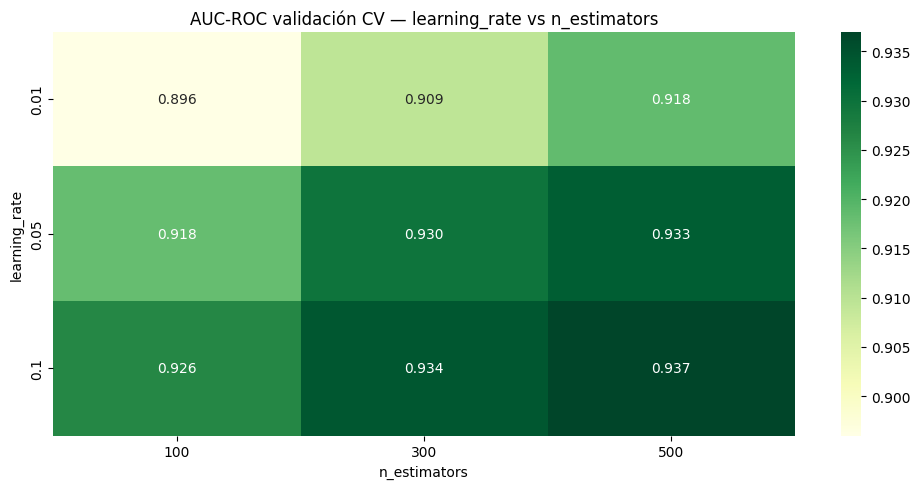

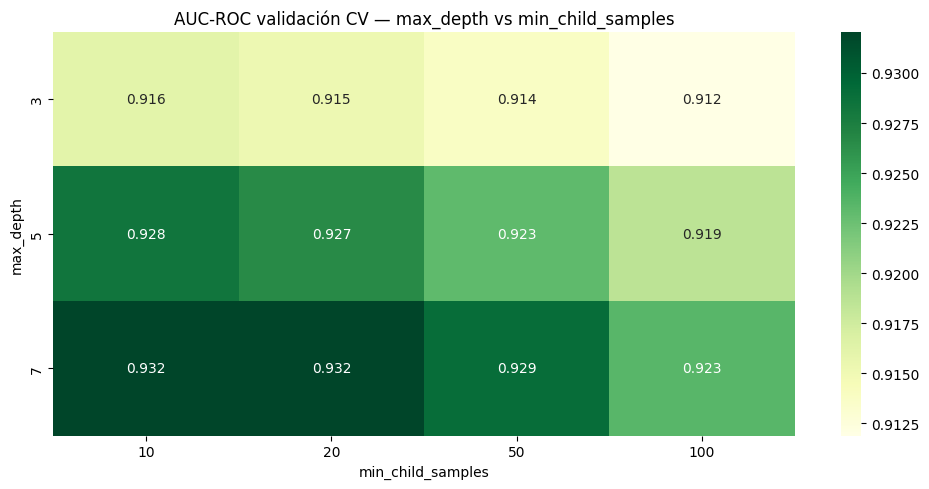

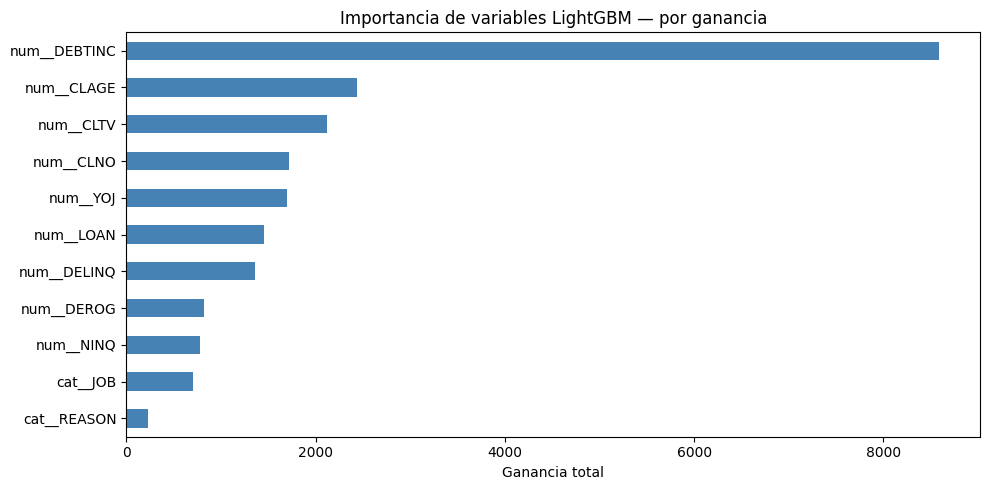

In [54]:
import seaborn as sns

# ── Preparación de la tabla de resultados ────────────────────────────────────
ac_df = pd.DataFrame(gs_lgbm.cv_results_["params"])
ac_df["auc_val"]   = gs_lgbm.cv_results_["mean_test_score"]
ac_df["auc_train"] = gs_lgbm.cv_results_["mean_train_score"]

# Limpiamos el prefijo del pipeline de los nombres de columnas
ac_df.columns = ac_df.columns.str.replace("model_light__", "", regex=False)

# ── Heatmap 1 — learning_rate vs n_estimators ────────────────────────────────
pivot_1 = ac_df.pivot_table(
    index="learning_rate",
    columns="n_estimators",
    values="auc_val",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(data=pivot_1, annot=True, fmt=".3f", cmap="YlGn")
plt.title("AUC-ROC validación CV — learning_rate vs n_estimators")
plt.tight_layout()
plt.show()

# ── Heatmap 2 — max_depth vs min_child_samples ───────────────────────────────
pivot_2 = ac_df.pivot_table(
    index="max_depth",
    columns="min_child_samples",
    values="auc_val",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(data=pivot_2, annot=True, fmt=".3f", cmap="YlGn")
plt.title("AUC-ROC validación CV — max_depth vs min_child_samples")
plt.tight_layout()
plt.show()

# ── Gráfico 3 — Importancia de variables por ganancia ────────────────────────
plt.figure(figsize=(10, 5))
importancias_gain.sort_values().plot(kind="barh", color="steelblue")
plt.title("Importancia de variables LightGBM — por ganancia")
plt.xlabel("Ganancia total")
plt.tight_layout()
plt.show()

Heatmap 1 — muestra si el AUC mejora con más árboles y si el learning_rate interactúa con n_estimators como esperamos. Las celdas más oscuras son las mejores combinaciones.  

Heatmap 2 — muestra cómo interactúan la complejidad del árbol (max_depth) y la regularización (min_child_samples). Nos permite ver si la zona de mejor AUC está en los extremos del grid o en el interior.  

Gráfico 3 — confirma qué variables contribuyen más al poder predictivo del modelo, en línea con el análisis de IV del EDA.

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: User

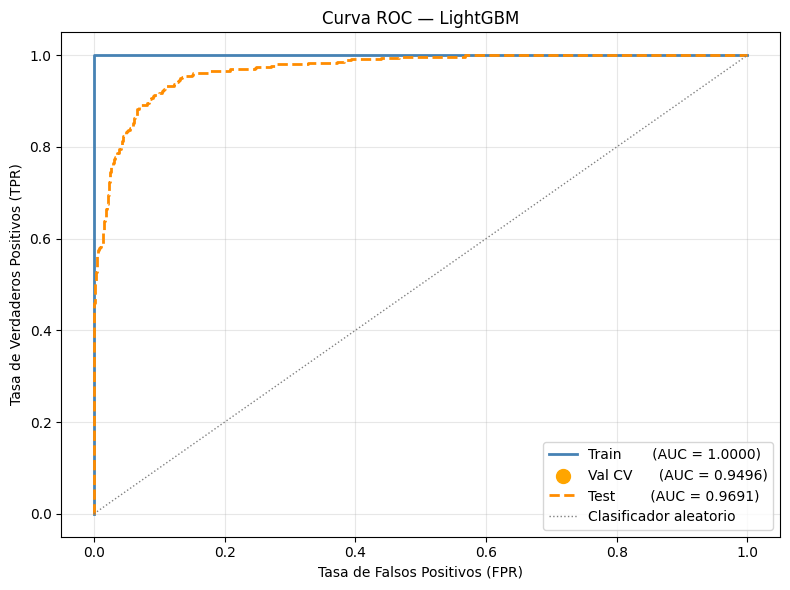

AUC-ROC train    : 1.0000
AUC-ROC val CV   : 0.9496
AUC-ROC test     : 0.9691


In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

# ── Probabilidades predichas ──────────────────────────────────────────────────

# Train — el modelo predice sobre los mismos datos con los que se entrenó
y_pred_proba_train = best_model_lgbm.predict_proba(X_train)[:, 1]

# Test — datos nunca vistos durante el entrenamiento
y_pred_proba_test  = best_model_lgbm.predict_proba(X_test)[:, 1]

# ── Curvas ROC ────────────────────────────────────────────────────────────────
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_pred_proba_test)

auc_train_final = roc_auc_score(y_train, y_pred_proba_train)
auc_val_final   = gs_lgbm.best_score_
auc_test_final  = roc_auc_score(y_test,  y_pred_proba_test)

# ── Gráfico ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# Curva train
plt.plot(fpr_train, tpr_train,
         label=f"Train       (AUC = {auc_train_final:.4f})",
         color="steelblue", linewidth=2)

# Curva validación CV — no tiene curva ROC directa, se representa como punto
plt.scatter([], [],
            label=f"Val CV      (AUC = {auc_val_final:.4f})",
            color="orange", s=100)

# Curva test
plt.plot(fpr_test, tpr_test,
         label=f"Test        (AUC = {auc_test_final:.4f})",
         color="darkorange", linewidth=2, linestyle="--")

# Línea de referencia — clasificador aleatorio
plt.plot([0, 1], [0, 1],
         color="gray", linewidth=1, linestyle=":", label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC — LightGBM")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC train    : {auc_train_final:.4f}")
print(f"AUC-ROC val CV   : {auc_val_final:.4f}")
print(f"AUC-ROC test     : {auc_test_final:.4f}")

La curva ROC del modelo LightGBM muestra una capacidad discriminante 
excelente en el conjunto de test (AUC-ROC = 0.9691), muy próxima al 
rendimiento en train (AUC-ROC = 1.0000). La distancia entre ambas curvas 
es reducida y se concentra en la zona de FPR bajo, donde el modelo es más 
selectivo. El AUC-ROC en validación cruzada (0.9496) actúa como estimación 
conservadora del rendimiento real, confirmada por el resultado en test. 
En conjunto, las tres métricas son consistentes con un modelo que generaliza 
correctamente a datos no vistos, descartando overfitting relevante.

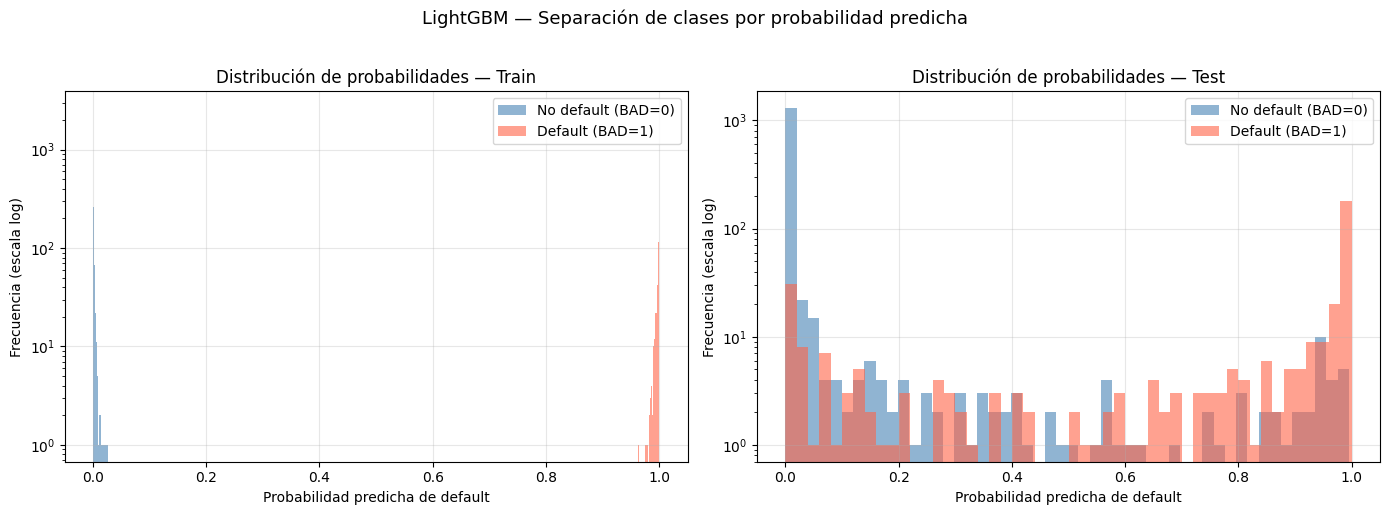

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train 
axes[0].hist(
    y_pred_proba_train[y_train == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[0].hist(
    y_pred_proba_train[y_train == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[0].set_yscale("log")                          # ← escala logarítmica
axes[0].set_title("Distribución de probabilidades — Train")
axes[0].set_xlabel("Probabilidad predicha de default")
axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(
    y_pred_proba_test[y_test == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[1].hist(
    y_pred_proba_test[y_test == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[1].set_yscale("log")                          # ← escala logarítmica
axes[1].set_title("Distribución de probabilidades — Test")
axes[1].set_xlabel("Probabilidad predicha de default")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LightGBM — Separación de clases por probabilidad predicha",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

La distribución de probabilidades predichas ilustra visualmente la naturaleza 
del overfitting detectado. En train, el modelo asigna probabilidades 
concentradas en los extremos — próximas a 0 para no defaults y próximas a 1 
para defaults — con separación prácticamente perfecta entre clases. En test, 
aparece solapamiento en la zona central (0.2–0.8), correspondiente a casos 
borderline donde las características del solicitante no permiten una 
clasificación inequívoca. Este solapamiento, ausente en train, explica la 
diferencia entre AUC-ROC train (1.0000) y AUC-ROC test (0.9691), y confirma 
que el modelo generaliza correctamente aunque no de forma perfecta.

<center>
~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.<br>
                          THIS IS THE END OF THE NOTEBOOK<br>
~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.~.<br>
</center>